# T026 · 激酶相似性：相互作用指纹

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Dominique Sydow, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Talia B. Kimber, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2021, [Volkamer 实验室, Charité](https://volkamerlab.org/)


## 本教程的目标

我们将根据可用复合物结构中检测到的蛋白质-配体相互作用来评估一组激酶之间的相似性。为此，我们使用 KLIFS 数据库中预计算的相互作用指纹（IFP）。

_注意_：我们关注正构激酶结合位点之间的相似性；变构结合位点的相似性不在讨论范围内。


### _理论_ 部分内容

* 激酶数据集
* 激酶相似性描述符：KLIFS 相互作用指纹
* 使用 `opencadd.databases.klifs` 获取 KLIFS 数据


### _实践_ 部分内容

* 定义目标激酶
* 检索和预处理数据
    * 建立远程 KLIFS 会话
    * 获取描述这些激酶的所有结构
    * 过滤结构
    * 获取结构的 IFP（如果可用）
    * 合并结构和 IFP 数据
* 展示激酶覆盖情况
* 比较结构
    * 将 IFP 准备为 `numpy` 数组
    * 计算成对 Jaccard 距离
* 将结构映射到激酶距离矩阵
* 保存激酶距离矩阵


### 参考文献

* 激酶数据集：[<i>Molecules</i> (2021), <b>26(3)</b>, 629](https://www.mdpi.com/1420-3049/26/3/629)
* 蛋白质数据银行
  * PDB URL：http://www.rcsb.org/
  * PDB 数据库：[<i>Acta Cryst.</i> (2002), <b>D58</b>, 899-907](https://doi.org/10.1107/S0907444902003451) 和 [<i>Structure</i> (2012), <b>20(3)</b>, 391-396](https://doi.org/10.1016/j.str.2012.01.010)
* KLIFS
  * KLIFS URL：https://klifs.net/
  * KLIFS 数据库：[<i>Nucleic Acid Res.</i> (2020), <b>49(D1)</b>, D562-D569](https://doi.org/10.1093/nar/gkaa895)
  * KLIFS 结合位点定义：[<i>J. Med. Chem.</i> (2014), <b>57(2)</b>, 249-277](https://doi.org/10.1021/jm400378w)
  * 相互作用指纹：[<i>J. Med. Chem.</i> (2014), <b>57(2)</b>, 249-277](https://doi.org/10.1021/jm400378w)
 * 结合位点比较综述：
   * [<i>Curr. Comput. Aided Drug Des. </i> (2008), <b>4</b>, 209-20](https://www.eurekaselect.com/67606/article/how-measure-similarity-between-protein-ligand-binding-sites)
    * [<i>J. Med. Chem. </i> (2016), <b>9</b>, 4121-51](https://pubs.acs.org/doi/10.1021/acs.jmedchem.6b00078)
* Jaccard 距离：[维基百科](https://en.wikipedia.org/wiki/Jaccard_index)
* `opencadd`
  * GitHub 仓库：https://github.com/volkamerlab/opencadd
  * 文档：https://opencadd.readthedocs.io


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 26
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论


### 激酶数据集


我们使用 **教程 T023** 中定义的激酶选择。


### 激酶相似性描述符：KLIFS 相互作用指纹

相互作用指纹（IFP）编码配体在结合位点中的结合模式。KLIFS 数据库已经预计算了所有可用结构之间的相互作用指纹，并存储在 KLIFS 数据库中。因此，我们可以在本教程中直接使用它们。

相互作用指纹（图 1）编码了由 PLIP 在激酶口袋的每个残基上检测到的相互作用（更多信息请参见 **教程 T016**）。KLIFS 中的结合位点由 85 个残基组成。如果在一个残基上检测到某种相互作用，则分配 1，否则分配 0。


在本教程中，我们感兴趣的是基于共晶配体在可用的激酶结构中的结合模式的相似性来评估一组激酶之间的相似性。

因此，我们假设如果两个激酶对同一配体具有相似的结合模式，那么它们本身也可能在结构上相似，并且新设计的配体也可能以相似的方式与它们相互作用。


这是相应 KLIFS 论文 [<i>J. Med. Chem.</i> (2014), <b>57(2)</b>, 249-277](https://doi.org/10.1021/jm400378w) 中对 IFP 的解释：

> 相互作用指纹（IFP）基于七个结构不同的非共价相互作用的组合，包括疏水接触、芳香族（面-面和边-面）相互作用、氢键（蛋白质作为供体和受体）、离子相互作用和金属配位。


这样就得到了一个 85 × 7 = 595 位的位向量。由于结合位点在所有激酶之间是对齐的，IFP 中的每个位位置都可以直接比较，从而使激酶之间的化合物模式相似性评估成为可能。


![KLIFS IFP](images/T026_KLIFS_IFP.png)

*图 1：*
KLIFS 相互作用指纹（IFP）定义：在激酶口袋的每个残基上检测七种相互作用类型。有关这些相互作用的视觉表示，请参见 **教程 T016**。


### 使用 `opencadd.databases.klifs` 获取 KLIFS 数据

`opencadd` 是一个用于结构化学信息学的 Python 库，由柏林 Charité 医学院的 [Volkamer 实验室](https://volkamerlab.org/) 开发。该库是一个不断增长的模块集合，有助于促进和标准化结构生物信息学和化学信息学中的常见任务。今天，我们将使用 `opencadd.databases.klifs` 模块，该模块允许我们以 `pandas` DataFrame 的形式获取 KLIFS 数据。

- GitHub 仓库：https://github.com/volkamerlab/opencadd
- 文档：https://opencadd.readthedocs.io

有关该库和 KLIFS OpenAPI 的更多信息，请参阅 **教程 T012**。


## 实践


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
from scipy.spatial import distance
from opencadd.databases.klifs import setup_remote

In [3]:
HERE = Path(_dh[-1])
DATA = HERE / "data"

In [4]:
configs = pd.read_csv(DATA / "pipeline_configs.csv")
configs = configs.set_index("variable")["default_value"]

DEMO = bool(int(configs["DEMO"]))
N_STRUCTURES_PER_KINASE = int(configs["N_STRUCTURES_PER_KINASE"])
N_CORES = int(configs["N_CORES"])

print(f"Run in demo mode: {DEMO}")
if not DEMO:
    if N_STRUCTURES_PER_KINASE > 0:
        print(f"Number of structures per kinase: {N_STRUCTURES_PER_KINASE}")
    else:
        print(f"Number of structures per kinase: all available structures")
    print(f"Number of cores used: {N_CORES}")

# NBVAL_CHECK_OUTPUT

Run in demo mode: True


### 定义目标激酶


加载 **教程 T023** 中定义的激酶选择。


In [5]:
kinase_selection_df = pd.read_csv(DATA / "kinase_selection.csv")
kinase_selection_df
# NBVAL_CHECK_OUTPUT

,kinase,kinase_klifs,uniprot_id,group,full_kinase_name
0,EGFR,EGFR,P00533,TK,Epidermal growth factor receptor
1,ErbB2,ErbB2,P04626,TK,Erythroblastic leukemia viral oncogene homolog 2
2,PI3K,p110a,P42336,Atypical,Phosphatidylinositol-3-kinase
3,VEGFR2,KDR,P35968,TK,Vascular endothelial growth factor receptor 2
4,BRAF,BRAF,P15056,TKL,Rapidly accelerated fibrosarcoma isoform B
5,CDK2,CDK2,P24941,CMGC,Cyclic-dependent kinase 2
6,LCK,LCK,P06239,TK,Lymphocyte-specific protein tyrosine kinase
7,MET,MET,P08581,TK,Mesenchymal-epithelial transition factor
8,p38a,p38a,Q16539,CMGC,p38 mitogen activated protein kinase alpha


### 检索和预处理数据


现在，我们使用 `opencadd.databases.klifs` 模块查询 KLIFS 数据库，以生成我们的 IFP 数据集。


#### 建立远程 KLIFS 会话


In [6]:
from opencadd.databases.klifs import setup_remote

In [7]:
klifs_session = setup_remote()

#### 获取描述这些激酶的所有结构


In [8]:
# 获取激酶名称列表
kinase_names = kinase_selection_df["kinase_klifs"].to_list()

# 获取这些激酶的所有可用结构
structures_df = klifs_session.structures.by_kinase_name(kinase_names=kinase_names)
# Keep only relevant columns
structures_df = structures_df[
    [
        "structure.klifs_id",
        "kinase.klifs_name",
        "species.klifs",
        "structure.dfg",
        "structure.resolution",
        "structure.qualityscore",
    ]
]
print(f"Number of structures: {len(structures_df)}")
print("Kinases:", *structures_df["kinase.klifs_name"].unique())

Number of structures: 2763
Kinases: CDK2 p38a EGFR ErbB2 MET LCK KDR BRAF p110a


#### 过滤结构

我们按不同标准过滤结构：

- 物种：人（human）
- 构象：DFG-in（活性激酶构象）
- 分辨率：≤ 3 Å
- 质量评分：≥ 6


In [9]:
structures_df = structures_df[
    (structures_df["species.klifs"] == "Human")
    & (structures_df["structure.dfg"] == "in")
    & (structures_df["structure.resolution"] <= 3)
    & (structures_df["structure.qualityscore"] >= 6)
]
print(f"Number of structures: {len(structures_df)}")
print("Kinases:", *structures_df["kinase.klifs_name"].unique())

Number of structures: 1820
Kinases: CDK2 p38a EGFR ErbB2 MET LCK KDR BRAF p110a


保存结构 KLIFS ID 以供下一步使用。


In [10]:
structure_klifs_ids = structures_df["structure.klifs_id"].to_list()
print(f"Number of structures: {len(structure_klifs_ids)}")

Number of structures: 1820


_演示模式说明_：为了方便我们维护教程，我们现在加载一组冻结的结构 KLIFS ID（2021-08-23），并继续使用这些数据。

_非演示模式说明_：你是否在配置文件中指定了 `N_STRUCTURES_PER_KINASE`？如果你设置了例如 3，我们将在下面根据分辨率和 KLIFS 质量评分选择每个激酶的前 3 个结构。


In [11]:
if DEMO:
    # 加载冻结的数据集
    print("Notebook 以演示模式运行 - 加载冻结的结构集。")
    structure_klifs_ids = pd.read_csv(DATA / "frozen_structure_klifs_ids.csv")[
        "structure.klifs_id"
    ].to_list()
    structures_df = structures_df[
        structures_df["structure.klifs_id"].isin(structure_klifs_ids)
    ].copy()
else:
    if N_STRUCTURES_PER_KINASE > 0:
        print(f"Select {N_STRUCTURES_PER_KINASE} structures per kinase for downstream analysis.")
        # Sort structures by kinase and quality
        structures_df = structures_df.sort_values(
            by=["kinase.klifs_name", "structure.resolution", "structure.qualityscore"],
            ascending=[True, True, False],
        )
        # Reduce number of structures per kinase
        structures_df = structures_df.groupby("kinase.klifs_name").head(N_STRUCTURES_PER_KINASE)
        structure_klifs_ids = structures_df["structure.klifs_id"].to_list()
    else:
        print(f"Use all available structures per kinase for downstream analysis.")

print(f"Number of structures: {structures_df.shape[0]}")
# NBVAL_CHECK_OUTPUT

Notebook is run in demo mode - load frozen structure set.
Number of structures: 1620


#### 获取结构的 IFP（如果可用）

我们获取这组结构的 IFP。并非所有结构都会有 IFP，因为并非所有结构都包含与激酶共晶的配体。


In [12]:
ifps_df = klifs_session.interactions.by_structure_klifs_id(structure_klifs_ids)
print(f"Number of structures with IFPs: {len(ifps_df)}")
ifps_df.head()

Number of structures with IFPs: 1466


,structure.klifs_id,interaction.fingerprint
0,775,0000000000000010000000000000000000000000000000...
1,777,0000000000000010000001000000000000000000000000...
2,778,0000000000000010000000000000000000000000000000...
3,779,0000000000000010000001000000000000000000000000...
4,782,0000000000000010000001000000000000000000000000...


#### 合并结构和 IFP 数据


In [13]:
structures_with_ifps_df = ifps_df.merge(structures_df, on="structure.klifs_id", how="inner")
print(f"Number of structures with IFPs: {len(structures_with_ifps_df)}")
structures_with_ifps_df.head()
# NBVAL_CHECK_OUTPUT

Number of structures with IFPs: 1466


,structure.klifs_id,interaction.fingerprint,kinase.klifs_name,species.klifs,structure.dfg,structure.resolution,structure.qualityscore
0,775,0000000000000010000000000000000000000000000000...,EGFR,Human,in,3.00,8.0
1,777,0000000000000010000001000000000000000000000000...,EGFR,Human,in,2.64,6.8
2,778,0000000000000010000000000000000000000000000000...,EGFR,Human,in,1.90,8.0
3,779,0000000000000010000001000000000000000000000000...,EGFR,Human,in,2.80,8.0
4,782,0000000000000010000001000000000000000000000000...,EGFR,Human,in,1.70,8.0


### 展示激酶覆盖情况

让我们获取描述我们激酶的结构数量（激酶覆盖情况）。


In [14]:
# 使用 pandas 的 groupby 方法统计每个激酶的结构数量
n_structures_per_kinase = structures_with_ifps_df.groupby("kinase.klifs_name").size().sort_values()
n_structures_per_kinase
# NBVAL_CHECK_OUTPUT

kinase.klifs_name
ErbB2      4
KDR        6
LCK       30
p110a     45
BRAF      57
MET       95
p38a     127
EGFR     339
CDK2     763
dtype: int64

绘制结果。


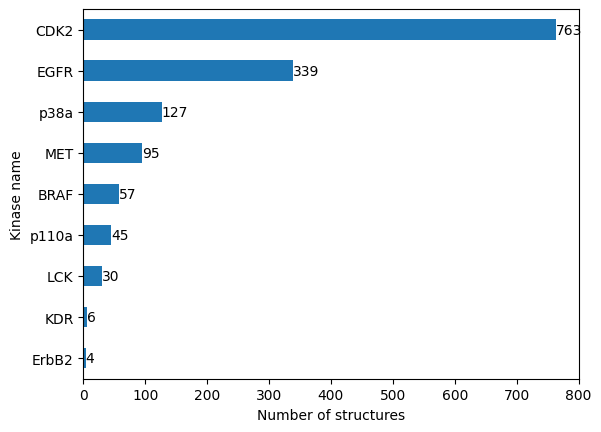

In [15]:
fig, ax = plt.subplots()
n_structures_per_kinase.plot(kind="barh", ax=ax)
ax.set_xlabel("Number of structures")
ax.set_ylabel("Kinase name")
for i, value in enumerate(n_structures_per_kinase):
    ax.text(value, i, str(value), va="center")

我们看到我们的数据集严重不平衡。虽然某些激酶被频繁解析出结构，但其他激酶则不然。在后续解释结果时，我们需要记住这一点。


### 比较结构

我们将使用 `sklearn.metrics` 中的 Tanimoto/Jaccard 距离对结构的 IFP 进行成对比较。


#### 将 IFP 准备为 `numpy` 数组

KLIFS 将 IFP 存储为 0 和 1 的字符串。我们必须将 IFP 转换为布尔向量数组（这是 `sklearn` 的 `pairwise_distances` 函数的要求）。


In [16]:
# This is the KLIFS format of the IFP (structure KLIFS ID and kinase name set as index)
ifp_series = structures_with_ifps_df.set_index(["structure.klifs_id", "kinase.klifs_name"])[
    "interaction.fingerprint"
]
ifp_series.head()
# NBVAL_CHECK_OUTPUT

structure.klifs_id  kinase.klifs_name
775                 EGFR                 0000000000000010000000000000000000000000000000...
777                 EGFR                 0000000000000010000001000000000000000000000000...
778                 EGFR                 0000000000000010000000000000000000000000000000...
779                 EGFR                 0000000000000010000001000000000000000000000000...
782                 EGFR                 0000000000000010000001000000000000000000000000...
Name: interaction.fingerprint, dtype: string

In [17]:
# Cast "0" and "1" to boolean False and True
ifp_series = ifp_series.apply(lambda x: [True if i == "1" else False for i in x])
ifp_series.head()
# NBVAL_CHECK_OUTPUT

structure.klifs_id  kinase.klifs_name
775                 EGFR                 [False, False, False, False, False, False, Fal...
777                 EGFR                 [False, False, False, False, False, False, Fal...
778                 EGFR                 [False, False, False, False, False, False, Fal...
779                 EGFR                 [False, False, False, False, False, False, Fal...
782                 EGFR                 [False, False, False, False, False, False, Fal...
Name: interaction.fingerprint, dtype: object

In [18]:
# Convert to numpy array
ifps_array = np.array(ifp_series.to_list())
ifps_array
# NBVAL_CHECK_OUTPUT

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

#### 计算成对 Jaccard 距离

Jaccard 距离通常用于二值指纹的情况，其定义如下：

$$
d_J(A,B) = 1 - J(A,B) = 1 - \frac{|A \cap B|}{|A \cup B|}
$$

如果两个位向量是相同的，则 Jaccard 距离为 0。如果两个位向量完全不同（没有共同的位），则 Jaccard 距离为 1。


In [19]:
structure_distance_matrix_array = pairwise_distances(ifps_array, metric="jaccard")

In [20]:
# Create DataFrame with structure KLIFS IDs as index/columns
structure_klifs_ids = ifp_series.index.get_level_values(0)
structure_distance_matrix_df = pd.DataFrame(
    structure_distance_matrix_array, index=structure_klifs_ids, columns=structure_klifs_ids
)
print(f"Structure distance matrix size: {structure_distance_matrix_df.shape}")
print("Show matrix subset:")
structure_distance_matrix_df.iloc[:5, :5]
# NBVAL_CHECK_OUTPUT

Structure distance matrix size: (1466, 1466)
Show matrix subset:


structure.klifs_id,775,777,778,779,782
structure.klifs_id,,,,,
775,0.000000,0.720000,0.542857,0.500000,0.483871
777,0.720000,0.000000,0.741935,0.500000,0.703704
778,0.542857,0.741935,0.000000,0.696970,0.411765
779,0.500000,0.500000,0.696970,0.000000,0.655172
782,0.483871,0.703704,0.411765,0.655172,0.000000


### 将结构映射到激酶距离矩阵

注意：到目前为止我们比较的是单个结构，但我们想要比较的是激酶（如上所述，每个激酶可能由多个结构表示）。

首先，作为一个中间步骤，我们将使用结构距离矩阵，但不是用结构 KLIFS ID 标记数据，而是使用对应的激酶名称。


In [21]:
# 复制距离矩阵到激酶矩阵
kinase_distance_matrix_df = structure_distance_matrix_df.copy()
# 将结构 KLIFS ID 替换为结构的激酶名称
kinase_names = ifp_series.index.get_level_values(1)
kinase_distance_matrix_df.index = kinase_names
kinase_distance_matrix_df.columns = kinase_names
print("Show matrix subset:")
kinase_distance_matrix_df.iloc[:5, :5]
# NBVAL_CHECK_OUTPUT

Show matrix subset:


kinase.klifs_name,EGFR,EGFR,EGFR,EGFR,EGFR
kinase.klifs_name,,,,,
EGFR,0.000000,0.720000,0.542857,0.500000,0.483871
EGFR,0.720000,0.000000,0.741935,0.500000,0.703704
EGFR,0.542857,0.741935,0.000000,0.696970,0.411765
EGFR,0.500000,0.500000,0.696970,0.000000,0.655172
EGFR,0.483871,0.703704,0.411765,0.655172,0.000000


一个激酶对可以由许多不同的结构对表示，这些结构对具有不同的距离值。

例如（在演示模式下），细胞周期蛋白依赖性激酶 CDK2 和 CDK4 由多个结构表示。因此，我们有一对一的"结构-结构"比较。


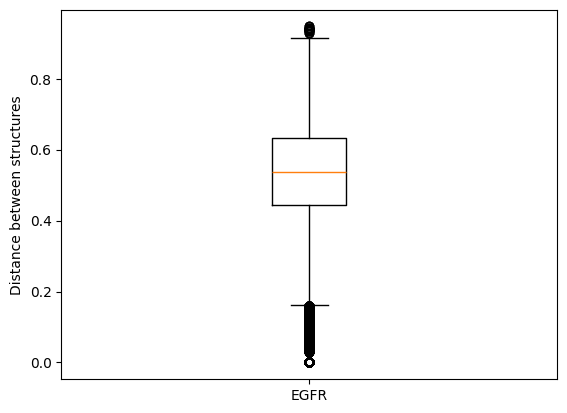

In [22]:
if DEMO:
    example = "EGFR"
else:
    example = kinase_selection_df["kinase_klifs"][0]

# Select EGFR-EGFR structure pairs only
D = kinase_distance_matrix_df.loc[example, example]
# Extract all pairwise distances without identical structure pairs
# = lower triangular matrix without the diagonal
D_condensed = distance.squareform(D)
# Plot pairwise distances
plt.boxplot(D_condensed)
plt.xticks([1], [example])
plt.ylabel("Distance between structures")
plt.show()

在本教程中，对于每对激酶，我们将考虑显示最相似的结合模式的两个结构。因此，我们选择距离最小的结构对作为该激酶对的代表。


In [23]:
# 展开矩阵（每个成对比较放在单独的行中）
# 按激酶名称分组（level=[0, 1] 确保忽略激酶的先后顺序）
# 取每个激酶对组中的最小值
# 展开剩余数据点

# 在展开前移除重复的列和行
# This ensures that both the index and the columns of the DataFrame are unique,
# which is required for the reshaping operation.

# Deduplicate columns (keeping first occurrence)
kinase_distance_matrix_df = kinase_distance_matrix_df.loc[
    :, ~kinase_distance_matrix_df.columns.duplicated()
]

# Deduplicate index (keeping first occurrence)
kinase_distance_matrix_df = kinase_distance_matrix_df.loc[
    ~kinase_distance_matrix_df.index.duplicated(), :
]

kinase_distance_matrix_df = (
    kinase_distance_matrix_df.unstack().groupby(level=[0, 1]).min().unstack(level=1)
)
kinase_distance_matrix_df.index.name = None
kinase_distance_matrix_df.columns.name = None

In [24]:
print(
    f"Structure matrix of shape {structure_distance_matrix_df.shape} "
    f"reduced to kinase matrix of shape {kinase_distance_matrix_df.shape}."
)
# NBVAL_CHECK_OUTPUT

Structure matrix of shape (1466, 1466) reduced to kinase matrix of shape (9, 9).


In [25]:
# Show matrix with background gradient
cm = sns.light_palette("green", as_cmap=True)
kinase_distance_matrix_df.style.background_gradient(cmap=cm).format("{:.3f}")

,BRAF,CDK2,EGFR,ErbB2,KDR,LCK,MET,p110a,p38a
BRAF,0.000,0.621,0.655,0.647,0.560,0.520,0.640,0.630,0.600
CDK2,0.621,0.000,0.594,0.632,0.600,0.567,0.621,0.697,0.741
EGFR,0.655,0.594,0.000,0.500,0.360,0.250,0.781,0.552,0.500
ErbB2,0.647,0.632,0.500,0.000,0.545,0.469,0.821,0.600,0.667
KDR,0.560,0.600,0.360,0.545,0.000,0.304,0.759,0.607,0.500
LCK,0.520,0.567,0.250,0.469,0.304,0.000,0.767,0.519,0.591
MET,0.640,0.621,0.781,0.821,0.759,0.767,0.000,0.767,0.727
p110a,0.630,0.697,0.552,0.600,0.607,0.519,0.767,0.000,0.708
p38a,0.600,0.741,0.500,0.667,0.500,0.591,0.727,0.708,0.000


注意：由于这是距离矩阵，较浅的颜色表示相似性，较深的颜色表示不相似性。


### 保存激酶距离矩阵


In [26]:
kinase_distance_matrix_df.to_csv(DATA / "kinase_distance_matrix.csv")

## 讨论

在本教程中，我们使用 KLIFS 相互作用指纹评估了激酶相似性，该指纹描述了共晶配体在激酶结构中的结合模式。我们通过为每个_激酶对_选择对应的最近_结构对_，将_结构_距离矩阵简化为_激酶_距离矩阵。

我们需要牢记一点：

- 相互作用指纹依赖于共晶配体的存在。因此，只能为具有已知共晶配体的激酶结构计算 IFP 相似性。此外，IFP 代表了特定配体的结合模式，如果包含不同的配体，这可能会使激酶比较产生偏差。

上述激酶距离矩阵将在 **教程 T028** 中重新加载，届时我们将从不同角度比较激酶相似性，包括本教程中讨论的 IFP 角度。


## 测验

1. 用相互作用指纹描述激酶相似性有哪些优缺点？
2. 为什么激酶的结构覆盖度在不同的激酶之间变化如此之大？你能否想到在哪些研究中，这种覆盖度可能比序列覆盖度更好或更差？
